In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

Before beginning exploratory data analysis (EDA), analysts should first understand variable types (nominal, ordinal, interval, ratio) and basic descriptive statistics (measures of central tendency, dispersion, and frequency distributions). This theoretical knowledge together with domain knowledge guides the choice of visualizations, summary statistics, and preprocessing steps during practical EDA.

Variable Types and Looking at Data

1.1 Variable Types 
Variables are things that can change (or vary). A variable that we think is a cause is referred to as an independent variable. In machine learning projects these variables are sometimes referred to as predictor variables. Dependent variables are variables whose behaviour is influenced by the independent variables. We think of these variables as effect variables or outcome variables. 

On a broader scale, variables can be classified as categorical or continuous and within these types, there exists different levels of measurement. 

Categorical variables are variables which can take on two or more different discrete values or categories. In the event that the variable can only take on two distinct types, we refer to this variable as a binary variable. When there are more than two possibilities, the variable is said to be a nominal variable. When categories are ordered, the variable is said to be ordinal. Only a hand full of arithmetic techniques can be applied to categorical variables for example measures of heterogeneity such as the gini index or entropy measurement are some popular analytic techniques. Continuous variables on the other hand, can be analysed using a lot more mathematical techniques they can take on any value on the selected measurement scale. Continuous variables which are measured on an interval scale are called interval variables. Similarly, continuous variables measured on ratio scale are called ratio variables 

When working with datasets (large or small), the different values that our variables can take on is our data. The EDA process aims to identify patterns within this data. This process begins with a data exploration phase where different charactersitics of the data are extracted or investigated. This exploration is critical as it reveals the fundamental structure of your data and helps prompt deeper and targeted investigation.

Investigating the characteristics of the data can take on various forms and mean anything from extracting the descriptive statistics, investigating the sample size and data dimensionality or assessing the data quality.  

1.2 Descriptive Statistics

Descriptive statistics give a summary of a dataset. The information drawn from descriptive statistics should not be used to make predictions or draw conclusions but should be used to gain an understanding of the information at a glance. 

Measures of central tendency:
Give an indication of where the centre of a frequency distribution lies.

Mode: The score that occurs the most. Can be easily identified and visualised in small datasets. Does not reveal much information if the data is bimodal or multimodal. 

Median: The centre score when scores are ranked in order of magnitude. Is relatively unaffected by outliers (extreme scores at either end of the distribution) and the skewness of the data.

Mean: The average score. Can be influenced by outliers and skewed distributions. 

Measures of dispersion:
These metrics quantify the spread of the data

Range: The smallest score subtracted from the largest score. Sensitive to outliers.

Interquartile range: The range of the middle 50% of the scores. Is less sensitive to extreme observations.
    
Variance: The spread of data points around the variable mean in a dataset

Standard Deviation: Also measures the spread of data points around the variable mean in the dataset. Is the square root of the variance

1.3 Frequency Distributions 
A frequency distribution is a graph of how many times each score occurs. 

Frequency distributions can take on different shapes. A normal distribution occurs when scores a re centred around the mean and is characterised by the bell-shaped curve. There are two main ways in which a distribution can deviate from normal; skewness and kurtosis.
    
A skewed distribution occurs when the most frequent scores are clustered at one end of the measurement scale. Skewed distributions can be positively or negatively skewed where positively skewed have a higher frequency of scores clustered at the lower end of the scale and negatively skewed distributions have a higher frequency of scores clustered at the higher end of the scale.

Kurtosis is the degree to which scores cluster at the ends of the distribution or how pointy the distribution is. A distribution with positive kurtosis has a sharp peak and heavier tails then the normal distribution. This type of distribution is called leptokurtic. A distribution with a negative kurtosis is called platykurtic and is characaterised by a flatter/broader peaks and has lighter tails.



EDA workflow:
1. Load data 
2. Inspect structure 
3. Check datatypes 
4. Check missing values 
5. Check duplicates
6. Explore distributions
7. Analyze categorical variables 
8. Analyze numerical variables 
9. Explore relationships 
10. Perform grouped analysis 
11. Generate visualisations
12. Summarise findings 

 This notebook will explore the non-clean version of shopping_trends.csv which can be downloaded at 
 https://www.kaggle.com/datasets/bhadramohit/customer-shopping-latest-trends-dataset?resource=download 

In python, we can get a brief understanding of our variables by inspecting the first few entries of the dataframe.

In [3]:
df = pd.read_csv('../data/raw/shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


We can get more information on the size of the data frame, 

In [13]:
df.shape

(3909, 17)

Get more information on the datatypes, and missing values within the dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

Get some descirptive statistics of the data such the mean, standard deviation, median, as well as other descriptive stats like the range which can be calculated using the information provided. There are other functions available within the pandas library which help extract the variance and many other stats.

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Although the ".info()" function will return the count of missing values for each variable or column, missing values can also be determined using,

In [6]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Duplicate values can be investigated using,

In [7]:
df.duplicated().sum()

np.int64(0)

Categorical variables can be analysed using the ".unique()" function. For a single column, df["col_name"].unique() is sufficient

In [9]:
df["Item Purchased"].unique()

<StringArray>
[    'Blouse',    'Sweater',      'Jeans',    'Sandals',   'Sneakers',
      'Shirt',     'Shorts',       'Coat',    'Handbag',      'Shoes',
      'Dress',      'Skirt', 'Sunglasses',      'Pants',     'Jacket',
     'Hoodie',    'Jewelry',    'T-shirt',      'Scarf',        'Hat',
      'Socks',   'Backpack',       'Belt',      'Boots',     'Gloves']
Length: 25, dtype: str

To inspect all non-numeric columns, one can use the 'is_string_dtype' from the pandas.api.types library

In [10]:
from pandas.api.types import is_string_dtype

columns = df.columns.tolist()

for column in columns:
    if is_string_dtype(df[column]):
        print(f"\n{column}:")
        print(df[column].unique())
    


Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Item Purchased:
<StringArray>
[    'Blouse',    'Sweater',      'Jeans',    'Sandals',   'Sneakers',
      'Shirt',     'Shorts',       'Coat',    'Handbag',      'Shoes',
      'Dress',      'Skirt', 'Sunglasses',      'Pants',     'Jacket',
     'Hoodie',    'Jewelry',    'T-shirt',      'Scarf',        'Hat',
      'Socks',   'Backpack',       'Belt',      'Boots',     'Gloves']
Length: 25, dtype: str

Category:
<StringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str

Location:
<StringArray>
[      'Kentucky',          'Maine',  'Massachusetts',   'Rhode Island',
         'Oregon',        'Wyoming',        'Montana',      'Louisiana',
  'West Virginia',       'Missouri',       'Arkansas',         'Hawaii',
       'Delaware',  'New Hampshire',       'New York',        'Alabama',
    'Mississippi', 'North Carolina',     'California',       'Oklahoma',
        'Florida',          'Texas', 

For smaller datasets visualations can be helpful in understanding how variables are distributed. Visualisations can help identify skewness, spread and outliers.

Note: The bin number selected has an impact on how the frequency distribution plot/histogram looks.

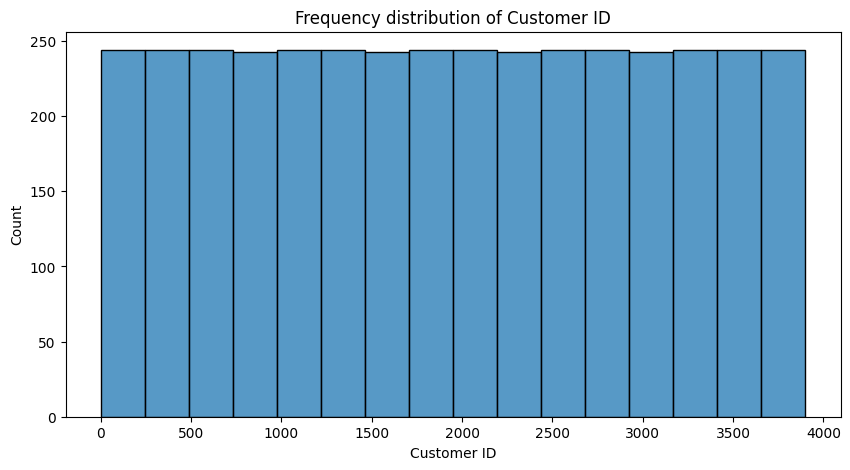

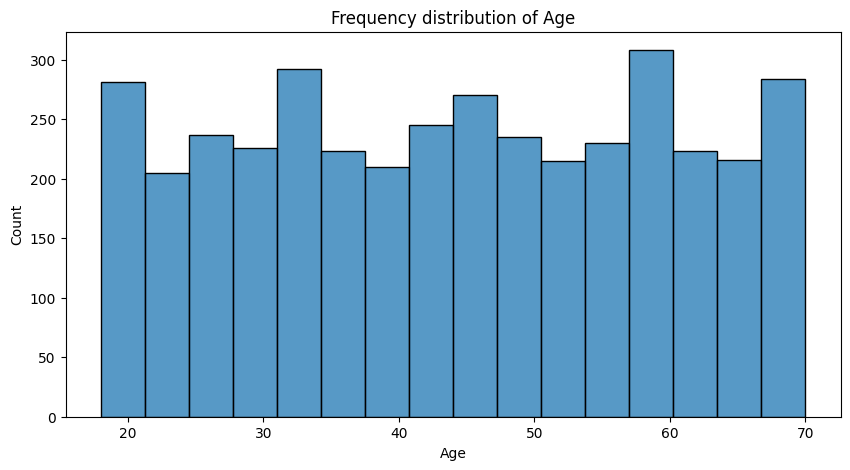

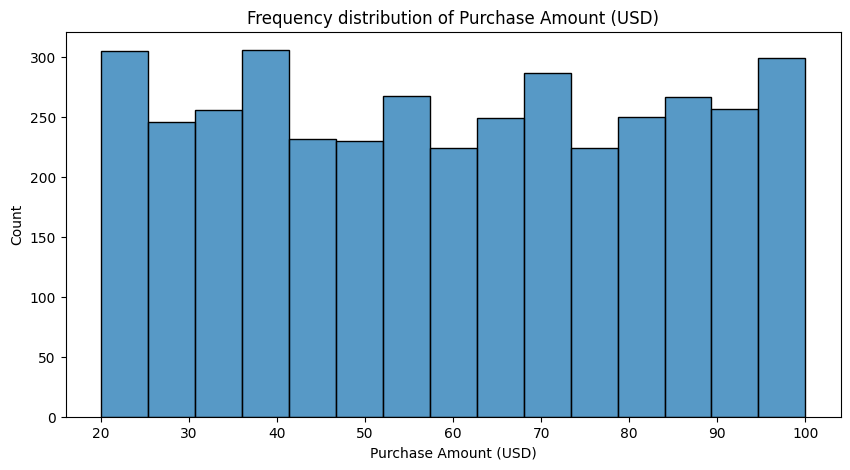

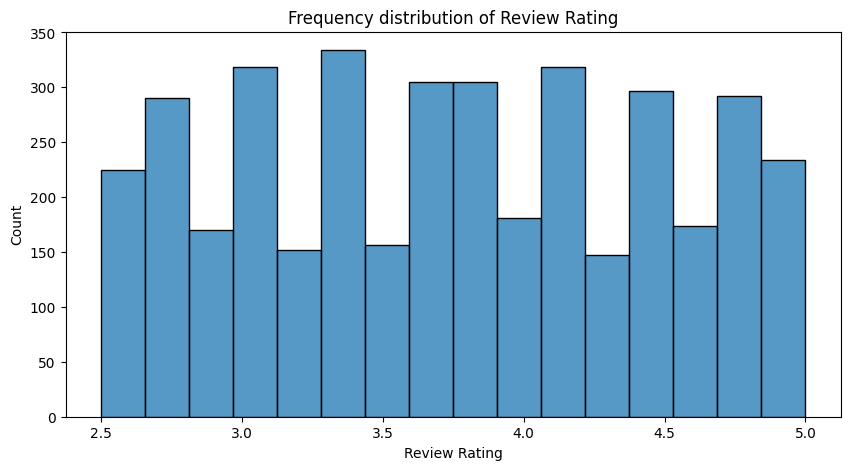

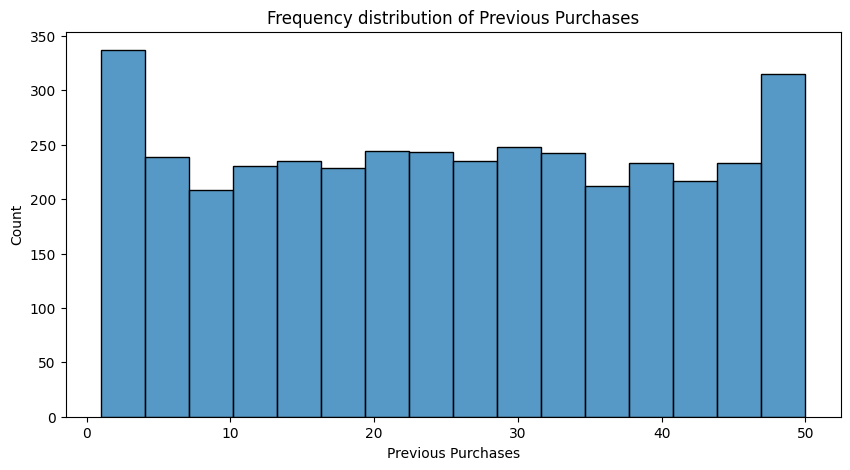

In [13]:
from pandas.api.types import is_numeric_dtype

for column in columns:
    if is_numeric_dtype(df[column]):
        plt.figure(f"{column}", figsize=(10,5))
        sns.histplot(df[column])  
        plt.title(f"Frequency distribution of {column}")
        plt.show()

The next code block also extracts the the frequency distribution of numeric numbers using a fixed bin number of 50. By increasing the number of bins, we get a more detailed distribution of frequency.

Another option is to set a fixed bin width which is especially useful when working with image data.

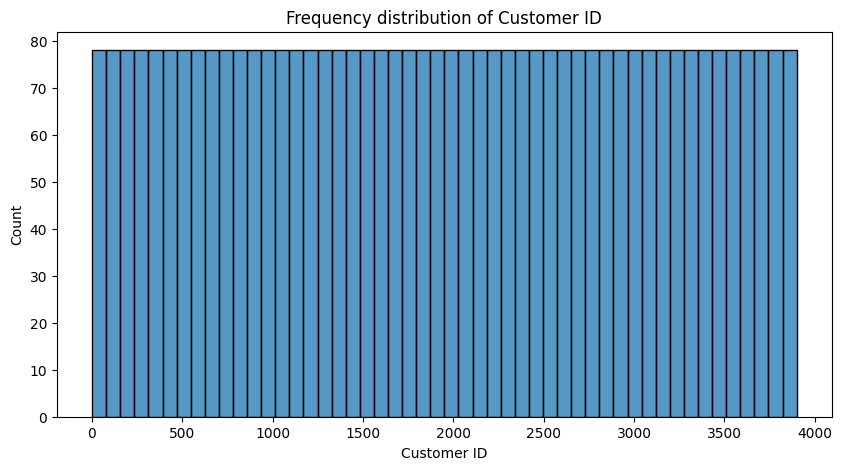

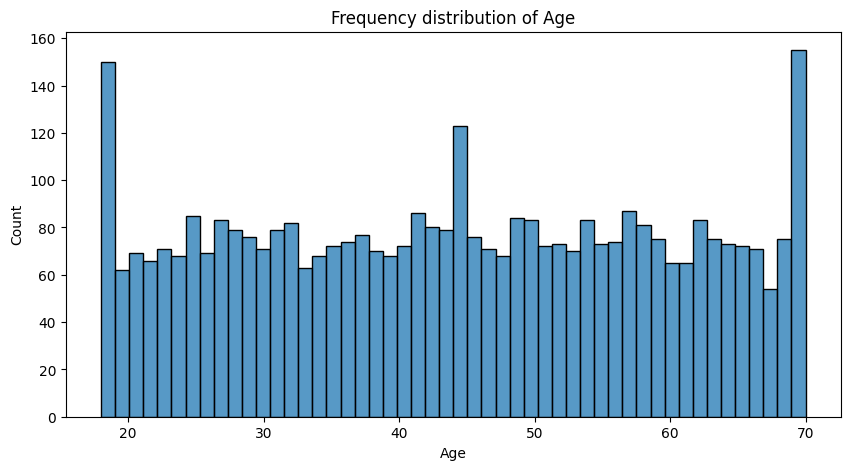

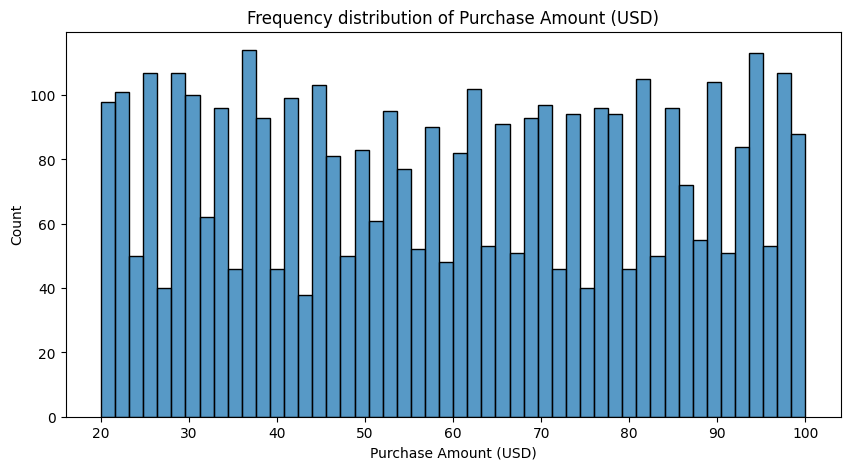

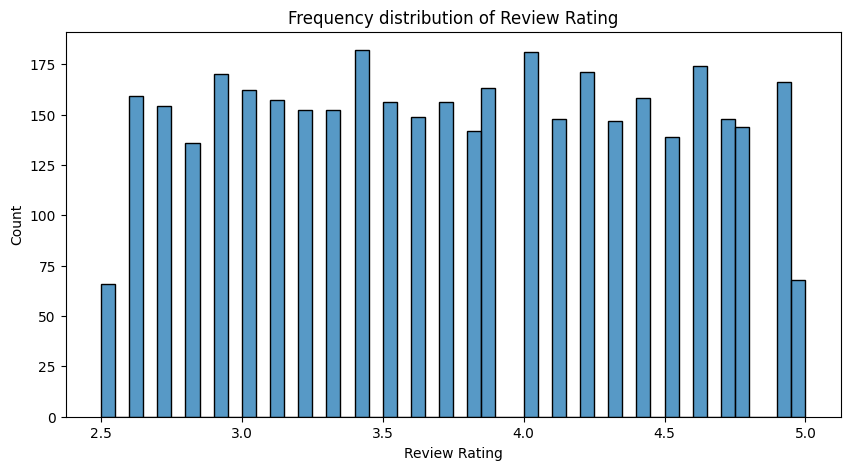

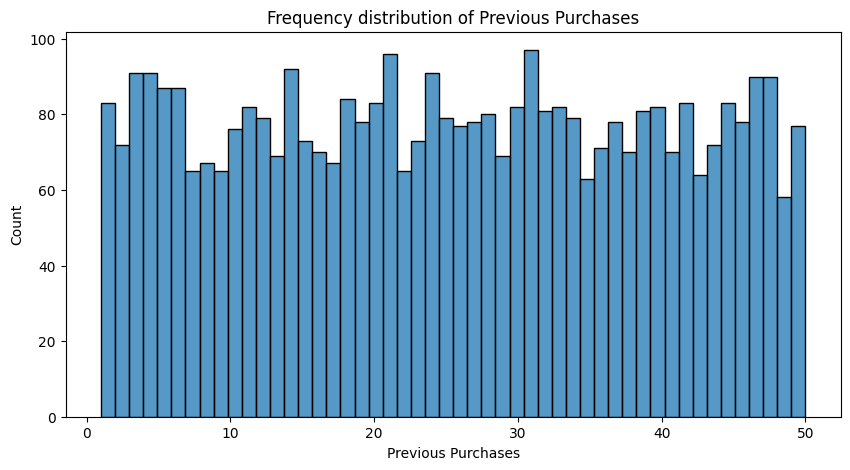

In [ ]:
for column in columns:
    if is_numeric_dtype(df[column]):
        plt.figure(f"{column}", figsize=(10,5))
        sns.histplot(df[column], bins =50)  
        plt.title(f"Frequency distribution of {column}")
        plt.show()

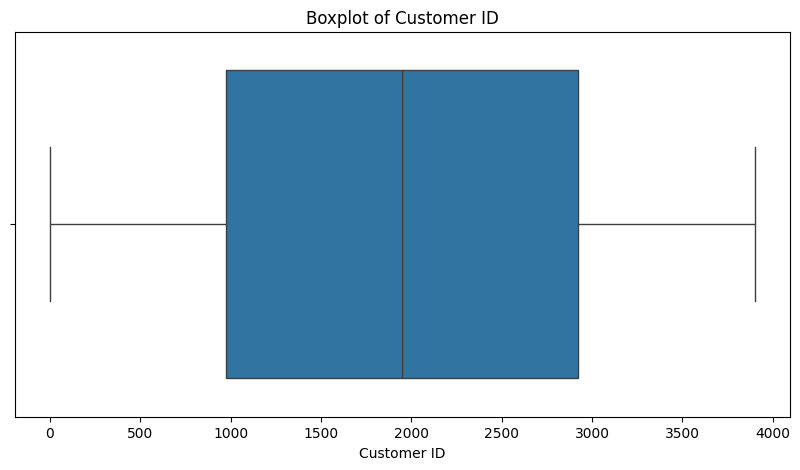

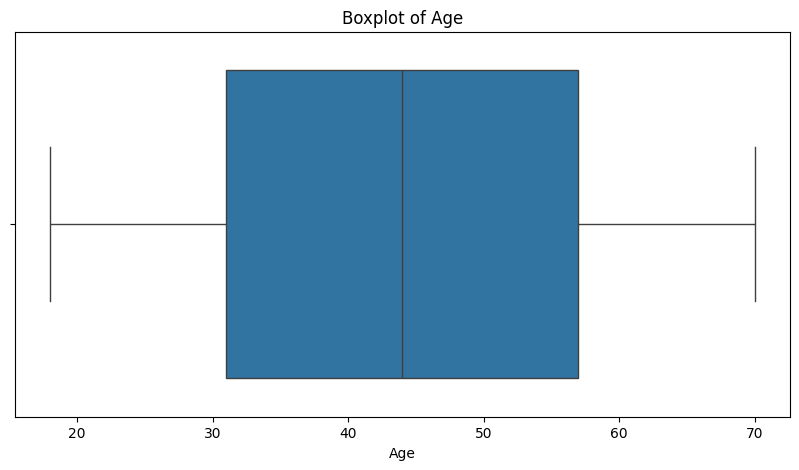

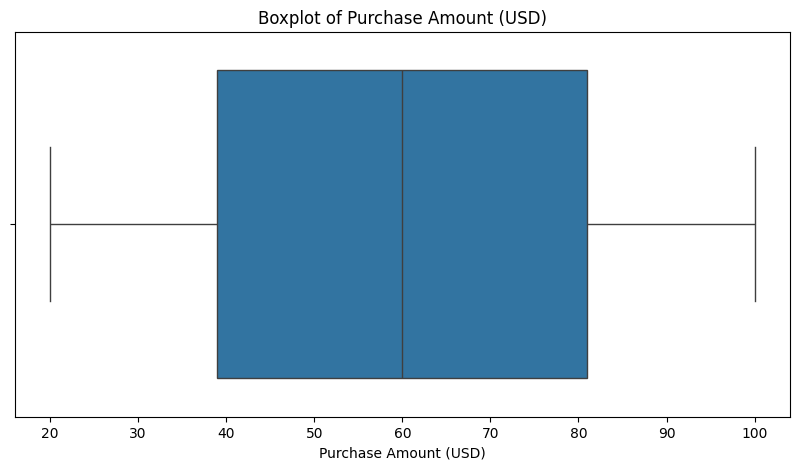

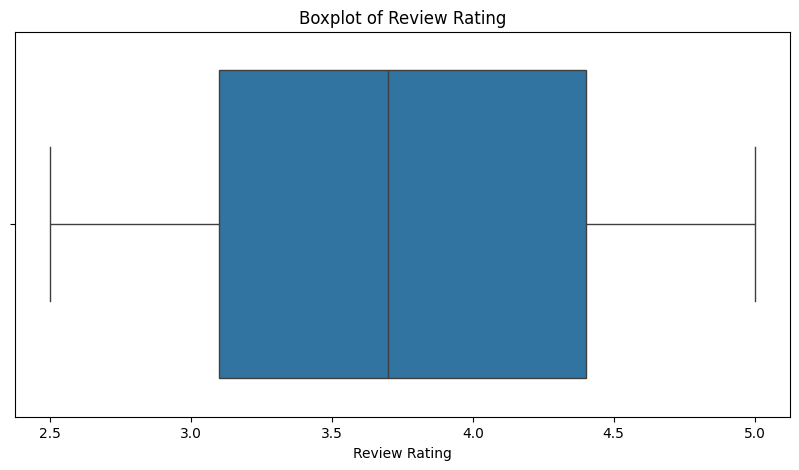

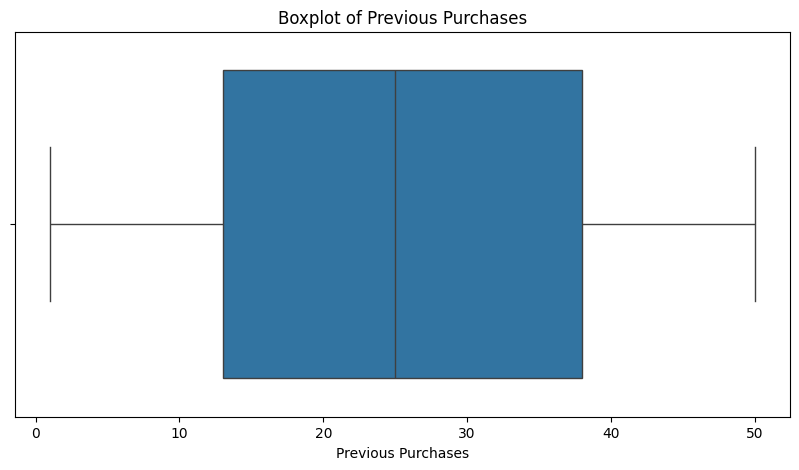

In [14]:
for column in columns:
    if is_numeric_dtype(df[column]):
        plt.figure(f"{column}", figsize=(10,5))
        sns.boxplot(x = df[column])  
        plt.title(f"Boxplot of {column}")
        plt.show()

The correlation between numeric variables can be determined quantitatively in a matrix but can also be visualised using heatmaps.

In [15]:
df.corr(numeric_only=True)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Customer ID,1.000000,-0.004079,0.011048,0.001343,-0.039159
Age,-0.004079,1.000000,-0.010424,-0.021949,0.040445
Purchase Amount (USD),0.011048,-0.010424,1.000000,0.030776,0.008063
Review Rating,0.001343,-0.021949,0.030776,1.000000,0.004229
Previous Purchases,-0.039159,0.040445,0.008063,0.004229,1.000000


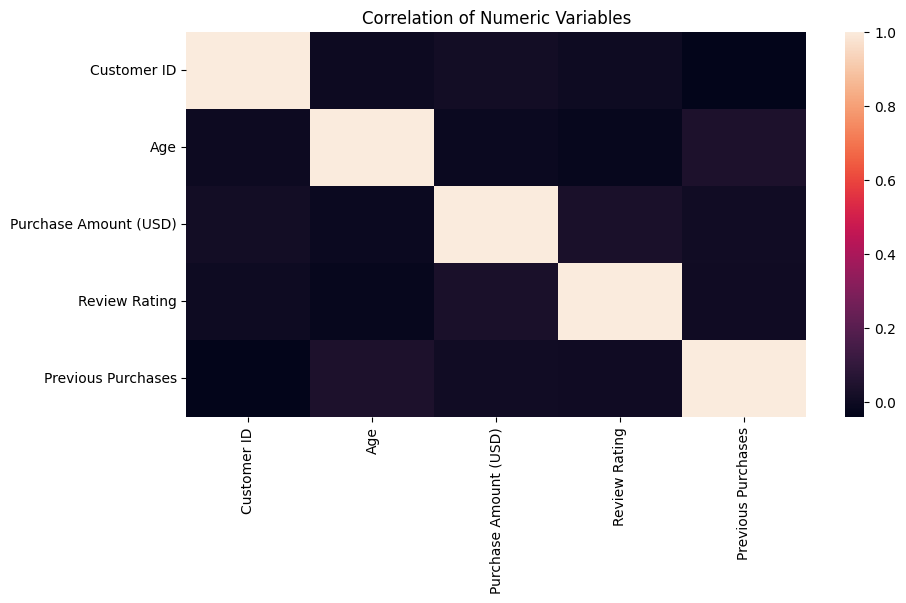

In [16]:
plt.figure("heatmap", figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation of Numeric Variables")
plt.show()

One can also perform grouped analysis and generate more interesting visualisations to start gaining some insights however this type of analysis may be more useful once the dataset has been cleaned.